# 01 — EDA: Activity Recognition Datasets

**Tarea A1 — Íñigo**

Objetivos:
- Visualizar señales temporales por actividad y por placement (cintura UCI HAR vs bolsillo MotionSense)
- Distribución de clases y duración media por actividad
- Comparar UCI HAR vs MotionSense: diferencias de distribución por placement
- Confirmar que `windowing.py` produce tensores `[N, 128, 6]` correctos
- Visualizar el efecto de la augmentation sobre una ventana ejemplo

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path('..').resolve()))
from src.preprocessing.windowing import (
    resample, butterworth_lowpass, normalize_subject,
    compute_svm, sliding_window,
    augment_axis_permutation, augment_gaussian_noise,
    augment_magnitude_scale, augment_time_warp, augment_window
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_RAW  = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

## 1. UCI HAR Dataset

Expected structure after download:
```
data/raw/UCI_HAR/
  UCI HAR Dataset/
    train/
      Inertial Signals/
        body_acc_x_train.txt  ...
        body_gyro_x_train.txt ...
      subject_train.txt
      y_train.txt
    test/
      ...
    activity_labels.txt
```

UCI HAR labels: 1=WALKING, 2=WALKING_UPSTAIRS, 3=WALKING_DOWNSTAIRS, 4=SITTING, 5=STANDING, 6=LAYING

In [2]:
UCI_ROOT = DATA_RAW / 'UCI_HAR' / 'UCI HAR Dataset'

UCI_LABEL_MAP = {
    1: 'walking',
    2: 'upstairs',
    3: 'downstairs',
    4: 'sitting',
    5: 'standing',
    6: 'laying',
}

def load_uci_split(split: str):
    """Load one split (train/test) from UCI HAR Inertial Signals.
    Returns X: (N, 128, 6), y: (N,), subjects: (N,)
    """
    sig_dir = UCI_ROOT / split / 'Inertial Signals'
    axes = ['x', 'y', 'z']
    channels = []
    for sensor in ['body_acc', 'body_gyro']:
        for ax in axes:
            fname = sig_dir / f'{sensor}_{ax}_{split}.txt'
            channels.append(np.loadtxt(fname))  # (N, 128)
    X = np.stack(channels, axis=-1).astype(np.float32)  # (N, 128, 6)
    y = np.loadtxt(UCI_ROOT / split / f'y_{split}.txt').astype(int)
    subjects = np.loadtxt(UCI_ROOT / split / f'subject_{split}.txt').astype(int)
    return X, y, subjects

print('Loading UCI HAR...')
X_train, y_train, subj_train = load_uci_split('train')
X_test,  y_test,  subj_test  = load_uci_split('test')
X_uci = np.concatenate([X_train, X_test])
y_uci = np.concatenate([y_train, y_test])
subj_uci = np.concatenate([subj_train, subj_test])
print(f'UCI HAR: X={X_uci.shape}, classes={np.unique(y_uci)}')

Loading UCI HAR...
UCI HAR: X=(10299, 128, 6), classes=[1 2 3 4 5 6]


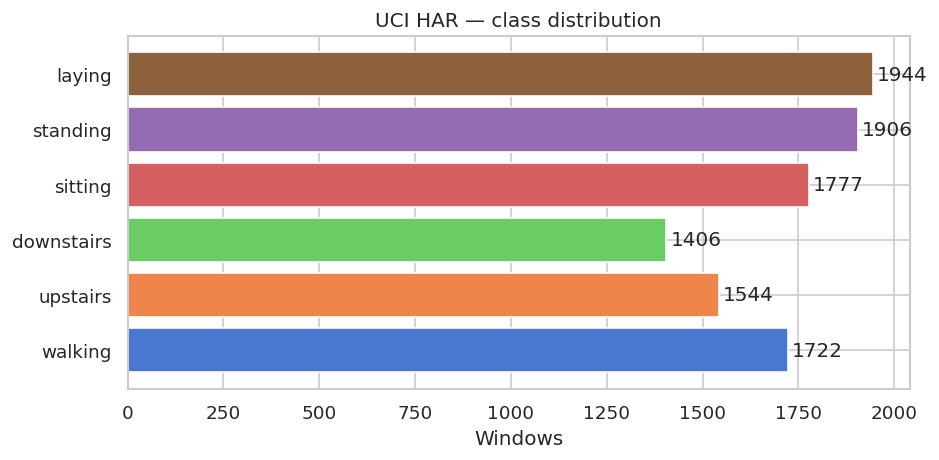

In [3]:
# Class distribution — UCI HAR
fig, ax = plt.subplots(figsize=(8, 4))
labels, counts = np.unique(y_uci, return_counts=True)
label_names = [UCI_LABEL_MAP[l] for l in labels]
ax.barh(label_names, counts, color=sns.color_palette('muted', len(labels)))
ax.set_xlabel('Windows')
ax.set_title('UCI HAR — class distribution')
for i, c in enumerate(counts):
    ax.text(c + 10, i, str(c), va='center')
plt.tight_layout()
plt.savefig(DATA_PROC / 'uci_class_dist.png', dpi=120)
plt.show()

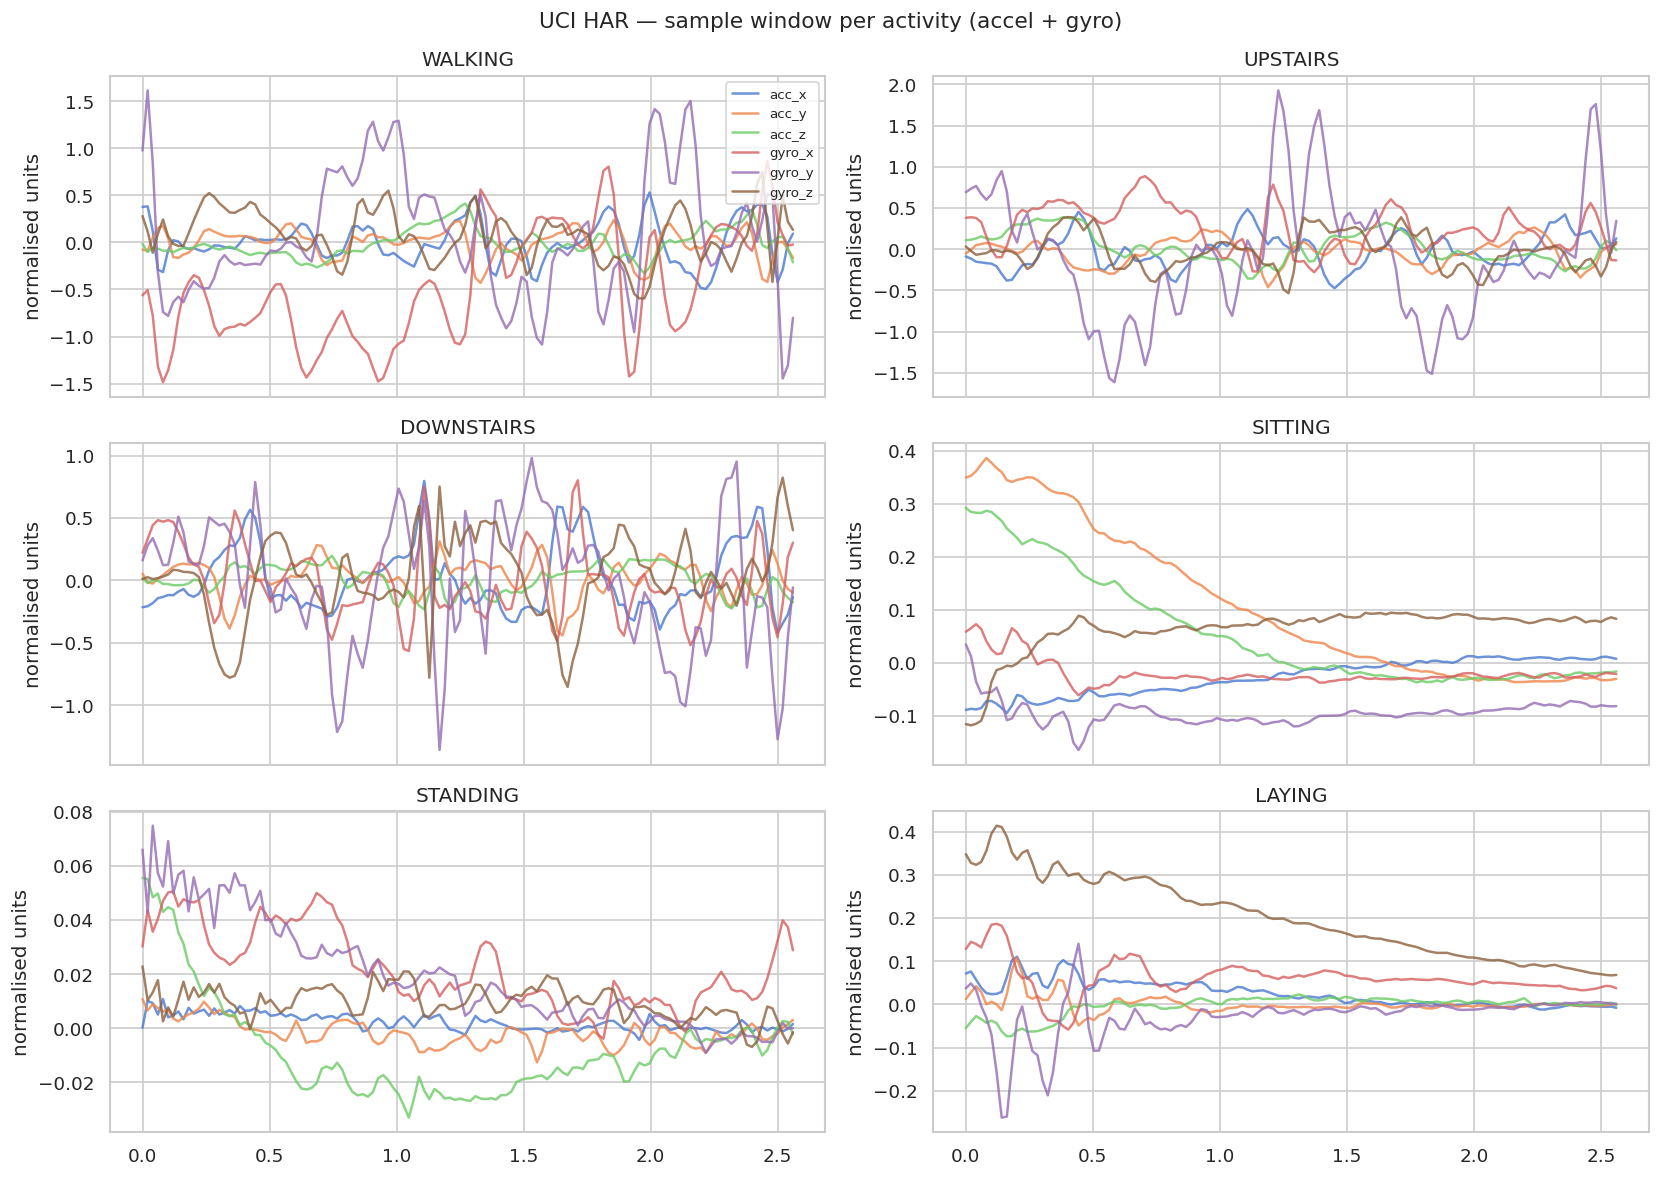

In [4]:
# Visualize raw signal per activity (first window of each class)
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
t = np.linspace(0, 2.56, 128)
channel_names = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

for idx, (label, name) in enumerate(UCI_LABEL_MAP.items()):
    ax = axes[idx // 2, idx % 2]
    mask = y_uci == label
    sample = X_uci[mask][0]  # first window
    for ch, ch_name in enumerate(channel_names):
        ax.plot(t, sample[:, ch], label=ch_name, alpha=0.8)
    ax.set_title(name.upper())
    ax.set_ylabel('normalised units')
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

fig.suptitle('UCI HAR — sample window per activity (accel + gyro)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROC / 'uci_signals_per_activity.png', dpi=120)
plt.show()

## 2. MotionSense Dataset

Expected structure after download:
```
data/raw/MotionSense/
  A_DeviceMotion_data/
    dws_1/  dws_2/  ...   (downstairs)
    ups_1/  ups_2/  ...   (upstairs)
    wlk_7/  ...           (walking)
    jog_9/  ...           (jogging/running)
    sit_13/ ...           (sitting)
    std_14/ ...           (standing)
      sub_1.csv  sub_2.csv  ...  (subject CSVs)
```
CSV columns: `attitude.roll, attitude.pitch, attitude.yaw, gravity.x, ..., userAcceleration.x/y/z, rotationRate.x/y/z`

We use: `userAcceleration.x/y/z` (g) + `rotationRate.x/y/z` (rad/s)

In [5]:
MS_ROOT = DATA_RAW / 'MotionSense' / 'A_DeviceMotion_data'

MS_LABEL_MAP = {
    'dws': 'downstairs',
    'ups': 'upstairs',
    'wlk': 'walking',
    'jog': 'running',
    'sit': 'sitting',
    'std': 'standing',
}

ACC_COLS  = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
GYRO_COLS = ['rotationRate.x', 'rotationRate.y', 'rotationRate.z']

def load_motionsense():
    """Load all MotionSense CSVs. Returns concatenated (signal, label, subject) arrays."""
    all_windows, all_labels, all_subjects = [], [], []
    for activity_dir in sorted(MS_ROOT.iterdir()):
        prefix = activity_dir.name.split('_')[0]
        if prefix not in MS_LABEL_MAP:
            continue
        label = list(MS_LABEL_MAP.keys()).index(prefix) + 1
        for csv_path in sorted(activity_dir.glob('sub_*.csv')):
            sub_id = int(csv_path.stem.split('_')[1])
            df = pd.read_csv(csv_path)
            if not all(c in df.columns for c in ACC_COLS + GYRO_COLS):
                continue
            signal = df[ACC_COLS + GYRO_COLS].values.astype(np.float32)  # (N, 6)
            # MotionSense is ~50 Hz but can vary — resample to 50 Hz
            signal = resample(signal, orig_hz=50, target_hz=50)  # no-op if already 50
            signal = butterworth_lowpass(signal, cutoff=20.0, fs=50.0)
            signal = normalize_subject(signal)
            windows = sliding_window(signal, window_size=128, overlap=0.5)
            if len(windows) == 0:
                continue
            all_windows.append(windows)
            all_labels.extend([label] * len(windows))
            all_subjects.extend([sub_id] * len(windows))
    X = np.concatenate(all_windows, axis=0)
    y = np.array(all_labels)
    subjects = np.array(all_subjects)
    return X, y, subjects

print('Loading MotionSense...')
X_ms, y_ms, subj_ms = load_motionsense()
print(f'MotionSense: X={X_ms.shape}, classes={np.unique(y_ms)}')

Loading MotionSense...
MotionSense: X=(21539, 128, 6), classes=[1 2 3 4 5 6]


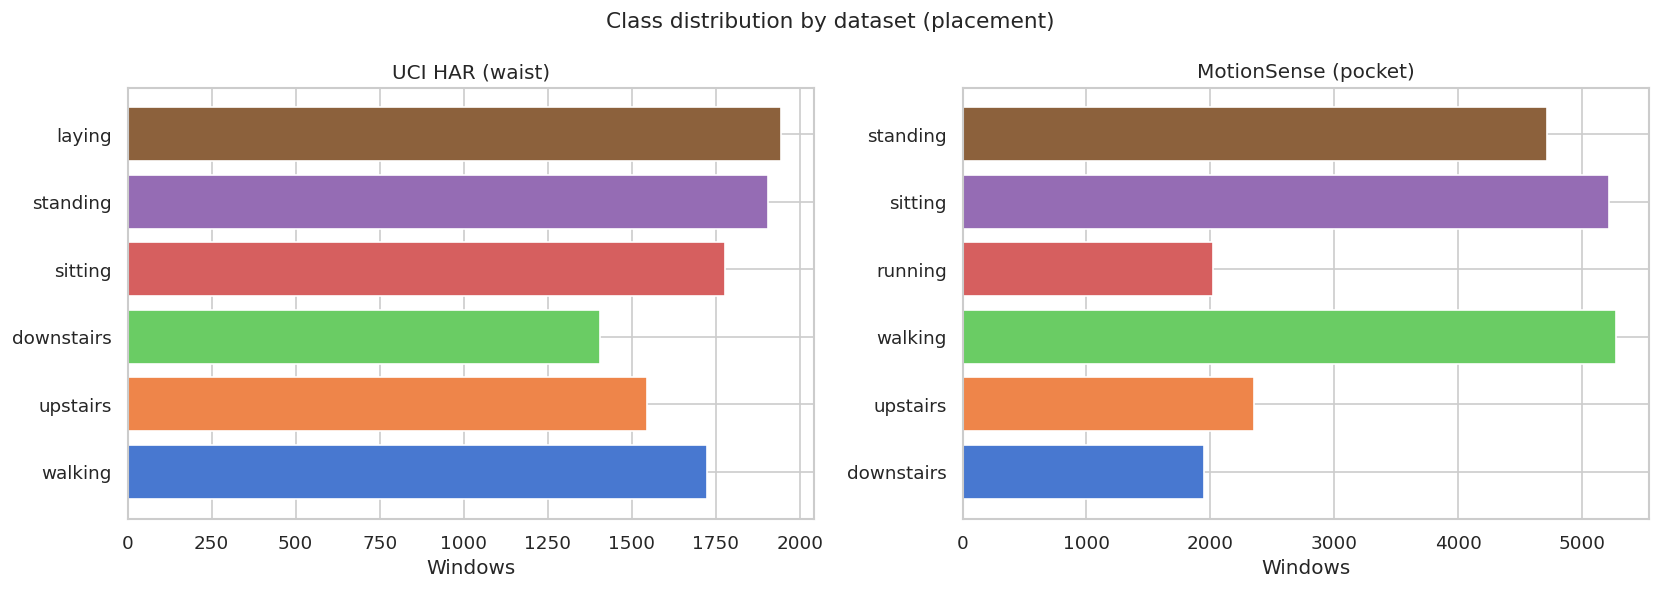

In [6]:
# Class distribution comparison: UCI HAR vs MotionSense
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (X, y, label_map, title) in zip(
    axes,
    [
        (X_uci, y_uci, {i+1: v for i,v in enumerate(UCI_LABEL_MAP.values())}, 'UCI HAR (waist)'),
        (X_ms, y_ms, {i+1: v for i,v in enumerate(MS_LABEL_MAP.values())}, 'MotionSense (pocket)'),
    ]
):
    labels_u, counts = np.unique(y, return_counts=True)
    names = [label_map.get(l, str(l)) for l in labels_u]
    ax.barh(names, counts, color=sns.color_palette('muted', len(labels_u)))
    ax.set_title(title)
    ax.set_xlabel('Windows')

fig.suptitle('Class distribution by dataset (placement)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROC / 'class_dist_comparison.png', dpi=120)
plt.show()

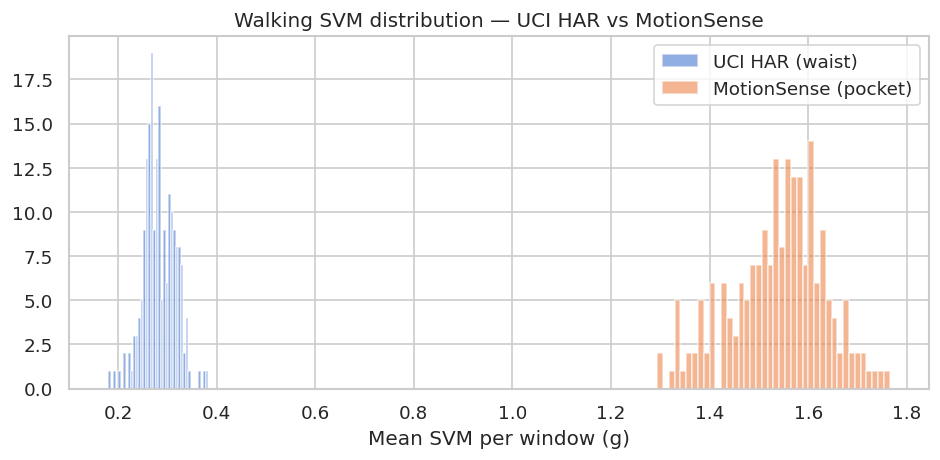

UCI HAR walking SVM mean: 0.284 g
MotionSense walking SVM mean: 1.538 g
Difference motivates placement-invariant augmentation (axis permutation, magnitude scale).


In [7]:
# SVM comparison by placement for walking windows
# UCI HAR: waist placement. MotionSense: pocket.
# Expect different amplitude distributions due to placement.

WALKING_LABEL_UCI = 1
WALKING_LABEL_MS  = list(MS_LABEL_MAP.keys()).index('wlk') + 1

uci_walk_svm  = [compute_svm(X_uci[i, :, :3]).mean() for i in np.where(y_uci == WALKING_LABEL_UCI)[0][:200]]
ms_walk_svm   = [compute_svm(X_ms[i, :, :3]).mean()  for i in np.where(y_ms  == WALKING_LABEL_MS)[0][:200]]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(uci_walk_svm, bins=40, alpha=0.6, label='UCI HAR (waist)')
ax.hist(ms_walk_svm,  bins=40, alpha=0.6, label='MotionSense (pocket)')
ax.set_xlabel('Mean SVM per window (g)')
ax.set_title('Walking SVM distribution — UCI HAR vs MotionSense')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / 'walking_svm_placement.png', dpi=120)
plt.show()

print(f'UCI HAR walking SVM mean: {np.mean(uci_walk_svm):.3f} g')
print(f'MotionSense walking SVM mean: {np.mean(ms_walk_svm):.3f} g')
print('Difference motivates placement-invariant augmentation (axis permutation, magnitude scale).')

## 3. Windowing module validation

Confirmar que `windowing.py` produce tensores `[N, 128, 6]` correctos con señal sintética.

In [8]:
# Smoke test windowing.py with a synthetic signal
np.random.seed(42)
t = np.linspace(0, 10, 500)  # 10 s @ 50 Hz
synthetic = np.stack([
    np.sin(2 * np.pi * 1.0 * t),   # 1 Hz walking-like
    np.sin(2 * np.pi * 1.0 * t + np.pi / 3),
    0.5 + 0.1 * np.random.randn(500),  # gravity component
    0.3 * np.sin(2 * np.pi * 2.0 * t),
    0.3 * np.cos(2 * np.pi * 2.0 * t),
    0.1 * np.random.randn(500),
], axis=1).astype(np.float32)

windows = sliding_window(synthetic, window_size=128, overlap=0.5)
assert windows.shape[1] == 128, f'Expected 128 samples, got {windows.shape[1]}'
assert windows.shape[2] == 6,   f'Expected 6 channels, got {windows.shape[2]}'
print(f'sliding_window OK: {windows.shape}  →  [N=?, 128, 6]')

# Confirm SVM computation
svm = compute_svm(windows[0, :, :3])
assert svm.shape == (128,), f'Expected (128,), got {svm.shape}'
print(f'compute_svm OK: shape={svm.shape}, mean={svm.mean():.3f} g')

# Confirm resample from 100 Hz to 50 Hz
signal_100hz = np.random.randn(200, 6).astype(np.float32)
signal_50hz  = resample(signal_100hz, orig_hz=100, target_hz=50)
assert signal_50hz.shape == (100, 6), f'Expected (100, 6), got {signal_50hz.shape}'
print(f'resample 100→50 Hz OK: {signal_100hz.shape} → {signal_50hz.shape}')

sliding_window OK: (6, 128, 6)  →  [N=?, 128, 6]
compute_svm OK: shape=(128,), mean=1.105 g
resample 100→50 Hz OK: (200, 6) → (100, 6)


## 4. Data augmentation — visual inspection

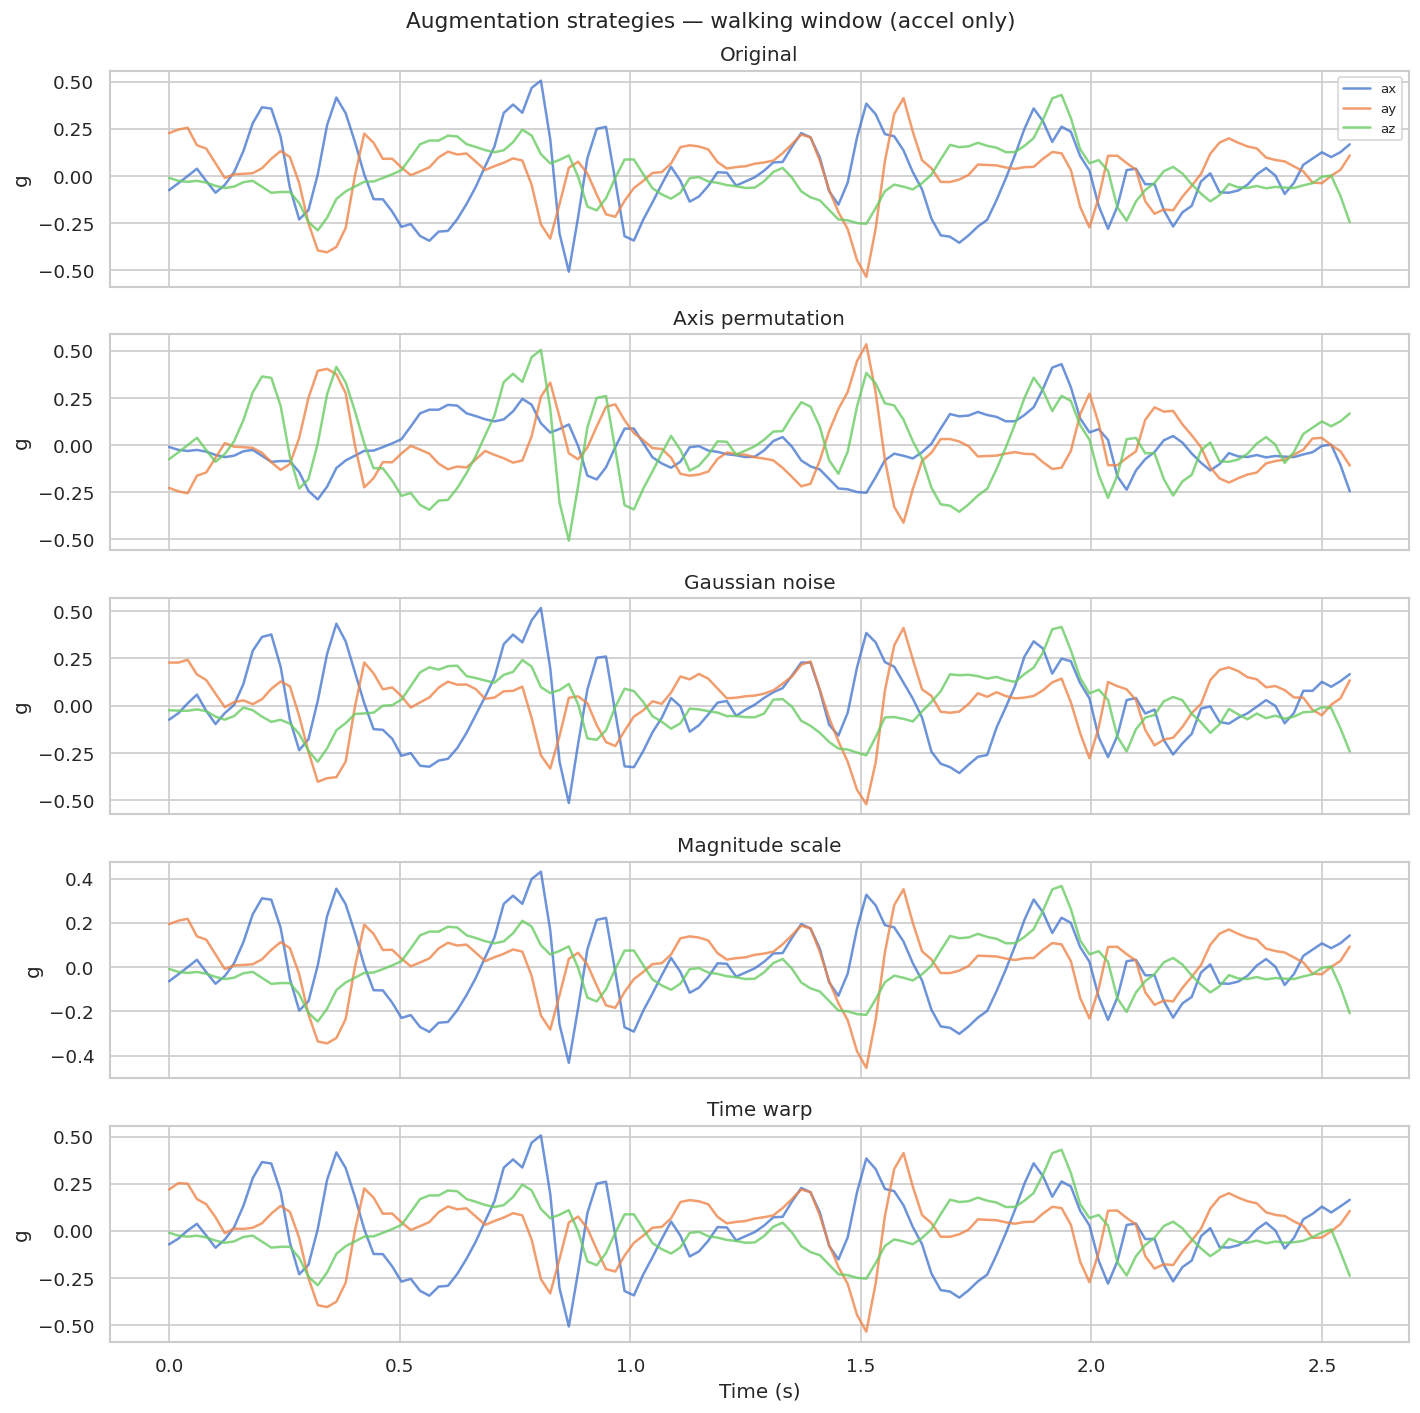

In [9]:
# Take one walking window from UCI HAR and show all augmentation effects
np.random.seed(0)
walking_mask = y_uci == 1
base_window = X_uci[walking_mask][42]  # (128, 6)

augmentations = {
    'Original': base_window,
    'Axis permutation': augment_axis_permutation(base_window),
    'Gaussian noise': augment_gaussian_noise(base_window),
    'Magnitude scale': augment_magnitude_scale(base_window),
    'Time warp': augment_time_warp(base_window),
}

t = np.linspace(0, 2.56, 128)
fig, axes = plt.subplots(len(augmentations), 1, figsize=(12, 12), sharex=True)

for ax, (name, win) in zip(axes, augmentations.items()):
    for ch in range(3):  # only accel channels for clarity
        ax.plot(t, win[:, ch], alpha=0.8, label=['ax', 'ay', 'az'][ch])
    ax.set_title(name)
    ax.set_ylabel('g')
    if name == 'Original':
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Augmentation strategies — walking window (accel only)', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_PROC / 'augmentation_comparison.png', dpi=120)
plt.show()

## 5. Save processed data for training

In [10]:
# Merge UCI HAR + MotionSense into a unified dataset
# Map both to the same label space: 1=walking,2=upstairs,3=downstairs,4=sitting,5=standing,6=running
# (UCI HAR has no running; MotionSense does via 'jog')

MS_TO_UNIFIED = {
    1: 3,  # dws → downstairs
    2: 2,  # ups → upstairs
    3: 1,  # wlk → walking
    4: 6,  # jog → running
    5: 4,  # sit → sitting
    6: 5,  # std → standing
}
# UCI HAR labels already map: 1=walk,2=upstairs,3=downstairs,4=sit,5=stand (6=laying → skip or merge w/ sitting)
UCI_TO_UNIFIED = {1: 1, 2: 2, 3: 3, 4: 4, 5: 5}  # drop 6 (laying) or keep as class 4

mask_uci = np.isin(y_uci, list(UCI_TO_UNIFIED.keys()))
X_uci_f = X_uci[mask_uci]
y_uci_f = np.array([UCI_TO_UNIFIED[l] for l in y_uci[mask_uci]])
s_uci_f = subj_uci[mask_uci]

y_ms_f = np.array([MS_TO_UNIFIED[l] for l in y_ms])
# Offset MotionSense subject IDs to avoid collision with UCI HAR IDs
s_ms_f = subj_ms + 100

X_all = np.concatenate([X_uci_f, X_ms], axis=0)
y_all = np.concatenate([y_uci_f, y_ms_f], axis=0)
s_all = np.concatenate([s_uci_f, s_ms_f], axis=0)

print(f'Unified dataset: {X_all.shape}, classes={np.unique(y_all)}')

np.save(DATA_PROC / 'X_activities.npy', X_all)
np.save(DATA_PROC / 'y_activities.npy', y_all)
np.save(DATA_PROC / 'subjects_activities.npy', s_all)
print('Saved to data/processed/')

Unified dataset: (29894, 128, 6), classes=[1 2 3 4 5 6]
Saved to data/processed/


In [11]:
# Final summary
UNIFIED_NAMES = {1: 'walking', 2: 'upstairs', 3: 'downstairs', 4: 'sitting', 5: 'standing', 6: 'running'}
print('=== Dataset summary ===')
print(f'Total windows : {len(X_all)}')
print(f'Subjects      : {len(np.unique(s_all))}')
print(f'Tensor shape  : {X_all.shape}  → [N, 128, 6] ✓')
print()
for label in sorted(np.unique(y_all)):
    count = (y_all == label).sum()
    print(f'  Class {label} ({UNIFIED_NAMES[label]:12s}): {count:5d} windows')

=== Dataset summary ===
Total windows : 29894
Subjects      : 54
Tensor shape  : (29894, 128, 6)  → [N, 128, 6] ✓

  Class 1 (walking     ):  6997 windows
  Class 2 (upstairs    ):  3894 windows
  Class 3 (downstairs  ):  3358 windows
  Class 4 (sitting     ):  6998 windows
  Class 5 (standing    ):  6622 windows
  Class 6 (running     ):  2025 windows
